# Ejercicio 3

Importe y explore el conjunto de datos `titanic.csv`.

1. Realice una descripción general del conjunto de datos que incluya la descripción de la información brindada por cada columna, el tipo de datos que contiene cada una y el número de registros.

2. Realice cualquier tipo de limpieza y adecuación del dataset que considere necesaria para su posterior análisis, incluyendo manejo de valores faltantes y de datos duplicados y/o potencialmente erróneos.

3. Calcule la media, la mediana y la desviación estándar de la edad de los/las pasajeros/as que murieron y sobrevivieron para cada clase. Realice un boxplot que muestre la distribución de edades para cada grupo (murieron/sobrevivieron) dentro de cada clase. ¿En qué clase las edades de las personas que sobrevivieron fueron más variables? ¿Cuál fue la edad de la persona más joven que sobrevivió en tercera clase?

4. Represente gráficamente la distribución de los precios de los pasajes en función de la clase del pasajero y calcule el promedio, la moda, la mediana, la desviación estándar y el rango intercuartil del precio del pasaje para cada grupo. ¿En qué clase los precios de pasaje presentaron una mayor variabilidad?

5. - ¿Qué medida resumen calcularía si quisiera conocer aquel valor que representa el precio que sólo el 25% de los pasajeros superaron a la hora de comprar su boleto?

    - Identifique cuáles fueron los pasajeros que pagaron un pasaje igual o más caro que el valor calculado en el ítem anterior. Construya una tabla en la que se informen los nombres de estas personas, el número total de personas vinculadas a ellas que se encontraban en el barco y la ciudad en la que embarcaron.

    - En base a la tabla construida en el ítem anterior, ¿con cuántos acompañantes, en promedio, viajaban estos pasajeros? ¿En qué puerto embarcó la mayoría de ellos?

6. Construya una tabla en la que se resuma la distribución de pasajeros del Titanic en función de la clase en la que viajaron. La misma debe contener la siguiente información (en distintas columnas): cantidad de pasajeros/as que viajaron en cada clase y porcentajes en relación al total. ¿A qué clase pertenecía la mayoría de los pasajeros del Titanic?

7. Construya una tabla de contingencia cruzando las variables `survived` y `Pclass`. ¿Qué proporción de personas de cada clase sobrevivieron al naufragio del Titanic? Represente gráficamente esta información en un gráfico de barras.

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
df = pd.read_csv("../datasets/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


## Item 1

Realice una descripción general del conjunto de datos que incluya la descripción de la información brindada por cada columna, el tipo de datos que contiene cada una y el número de registros

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   str    
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   str    
 16  Boarded      1304 non-null   str    
 17  Destination  1304 non-null   str    
 18  Lifeboat     502 non-null    str    
 19  Body         130 

In [107]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body',
       'Class'],
      dtype='str')

## Item 2

Realice cualquier tipo de limpieza y adecuación del dataset que considere necesaria para su posterior análisis, incluyendo manejo de valores faltantes y de datos duplicados y/o potencialmente erróneos.

El dataset presenta 1309 registros y 21 variables, incluyendo información demográfica, económica y del viaje de los pasajeros del Titanic.

Se identificaron valores faltantes en variables como `Age`, `Fare`, `Embarked` y `Survived`, así como columnas con gran cantidad de datos ausentes (por ejemplo, `Cabin`, `Body` y `Lifeboat`), las cuales fueron eliminadas debido a su escasa utilidad analítica.

Asimismo, se detectaron variables redundantes provenientes de otras fuentes (como `Age_wiki`, `Name_wiki`, `Boarded` y `Class`), que fueron removidas para evitar duplicidad de información.

Los valores faltantes en Age y Fare fueron imputados mediante la mediana, mientras que en Embarked se utilizó la moda. Finalmente, se eliminaron los registros sin información en la variable Survived, ya que son necesarios para el análisis de supervivencia.

In [108]:
# NA
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
WikiId            5
Name_wiki         5
Age_wiki          7
Hometown          5
Boarded           5
Destination       5
Lifeboat        807
Body           1179
Class             5
dtype: int64

In [109]:
df = df.drop(columns=["Cabin", "Body", "Lifeboat","Name_wiki", "Age_wiki",
                        "WikiId", "Hometown", "Destination", "Boarded", "Class"
                        ])

In [110]:
# Edad
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fare
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [111]:
df = df[df["Survived"].notna()]

In [112]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Item 3

Calcule la media, la mediana y la desviación estándar de la edad de los/las pasajeros/as que murieron y sobrevivieron para cada clase. Realice un boxplot que muestre la distribución de edades para cada grupo (murieron/sobrevivieron) dentro de cada clase. ¿En qué clase las edades de las personas que sobrevivieron fueron más variables? ¿Cuál fue la edad de la persona más joven que sobrevivió en tercera clase?

In [113]:
df.groupby(["Pclass", "Survived"])["Age"].agg(["mean", "median", "std"])

mean  median        std
Pclass Survived                              
1      0.0       40.556250    38.5  15.040240
       1.0       34.609706    33.5  13.219438
2      0.0       33.144330    30.0  11.788713
       1.0       25.998046    28.0  14.495355
3      0.0       26.951613    28.0  10.523063
       1.0       22.747227    27.0  10.656174

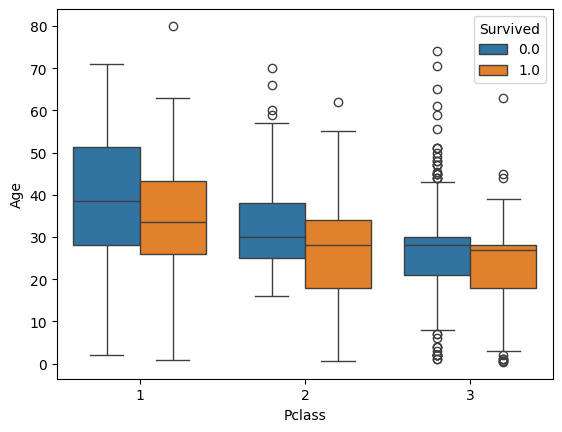

In [114]:
sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df)
plt.show()

In [115]:
persona = df[(df["Pclass"] == 3) & (df["Survived"] == 1)]["Age"].min()

print(f'La mayor variabilidad en la edad de los sobrevivientes se observa en la clase 1, \
lo cual se evidencia en la amplitud del rango intercuartil en el boxplot.\n\n\
La persona más joven que sobrevivió en tercera clase tenía {persona} años.')

La mayor variabilidad en la edad de los sobrevivientes se observa en la clase 1, lo cual se evidencia en la amplitud del rango intercuartil en el boxplot.

La persona más joven que sobrevivió en tercera clase tenía 0.42 años.


## Item 4

Represente gráficamente la distribución de los precios de los pasajes en función de la clase del pasajero y calcule el promedio, la moda, la mediana, la desviación estándar y el rango intercuartil del precio del pasaje para cada grupo. ¿En qué clase los precios de pasaje presentaron una mayor variabilidad?

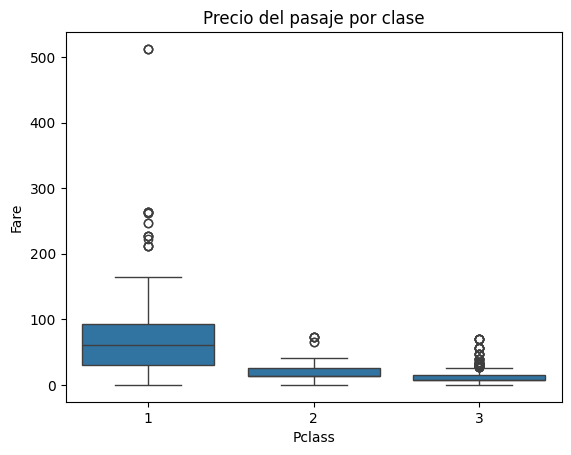

In [125]:
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Precio del pasaje por clase")
plt.show()

In [126]:
df.groupby("Pclass")["Fare"].agg(["mean", "median", "std",
                                    lambda x: x.quantile(0.75) - x.quantile(0.25),
                                    lambda x: x.mode()[0]
                                ]).rename(columns={
                                    "<lambda_0>": "ri",
                                    "<lambda_1>": "mode"
                                })

,mean,median,std,ri,mode
Pclass,,,,,
1,84.154687,60.2875,78.380373,62.57605,26.55
2,20.662183,14.2500,13.417399,13.00000,13.00
3,13.675550,8.0500,11.778142,7.75000,8.05


A partir del análisis de las medidas descriptivas y del boxplot, se observa que la primera clase presenta la mayor variabilidad en los precios de los pasajes. Esto se evidencia en valores más elevados del rango intercuartil y del desvío estándar, así como en la presencia de valores atípicos altos. Esto se debe a que en primera clase existía una mayor diversidad en los precios, posiblemente asociada a distintos niveles de lujo y servicios ofrecidos.

## Item 5

In [118]:
# ¿Qué medida resumen calcularía si quisiera conocer aquel valor que representa 
# el precio que sólo el 25% de los pasajeros superaron a la hora de comprar su boleto?

q75 = df["Fare"].quantile(0.75)
print('La medida es el percentil 75 y, en este caso, vale', q75)

La medida es el percentil 75 y, en este caso, vale 31.0


In [139]:
# Identifique cuáles fueron los pasajeros que pagaron un pasaje igual o más caro que 
# el valor calculado en el ítem anterior. Construya una tabla en la que se informen los 
# nombres de estas personas, el número total de personas vinculadas a ellas que se 
# encontraban en el barco y la ciudad en la que embarcaron.

top = df[df["Fare"] >= q75].copy()

top["acompanantes"] = top["SibSp"] + top["Parch"]

tabla_2 = top[["Name", "acompanantes", "Embarked"]]
tabla_2

,Name,acompanantes,Embarked
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,C
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,S
6,"McCarthy, Mr. Timothy J",0,S
13,"Andersson, Mr. Anders Johan",6,S
23,"Sloper, Mr. William Thompson",0,S
...,...,...,...
856,"Wick, Mrs. George Dennick (Mary Hitchcock)",2,S
863,"Sage, Miss. Dorothy Edith ""Dolly""",10,S
867,"Roebling, Mr. Washington Augustus II",0,S
871,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",2,S


In [136]:
# En base a la tabla construida en el ítem anterior, ¿con cuántos acompañantes, en promedio, 
# viajaban estos pasajeros? ¿En qué puerto embarcó la mayoría de ellos?

print('El promedio es:', round(tabla["acompanantes"].mean(),2),'. La mayoría embarcó en el puerto:', tabla["Embarked"].mode()[0],'(Southampton)')

El promedio es: 1.92 . La mayoría embarcó en el puerto: S (Southampton)


## Item 6

Construya una tabla en la que se resuma la distribución de pasajeros del Titanic en función de la clase en la que viajaron. La misma debe contener la siguiente información (en distintas columnas): cantidad de pasajeros/as que viajaron en cada clase y porcentajes en relación al total. ¿A qué clase pertenecía la mayoría de los pasajeros del Titanic?

In [138]:
freq = df["Pclass"].value_counts().sort_index()
porc = df["Pclass"].value_counts(normalize=True).sort_index() * 100

tabla_3 = pd.DataFrame({"cantidad": freq, "porcentaje": porc})

tabla_3

,cantidad,porcentaje
Pclass,,
1,216,24.242424
2,184,20.650954
3,491,55.106622


A partir de la tabla de distribución se observa que la mayoría de los pasajeros pertenecía a la tercera clase, ya que presenta la mayor frecuencia absoluta y relativa dentro del conjunto de datos. Esto refleja la composición socioeconómica del pasaje, donde predominaban los pasajeros de clases más bajas.

## item 7

Construya una tabla de contingencia cruzando las variables `survived` y `Pclass`. ¿Qué proporción de personas de cada clase sobrevivieron al naufragio del Titanic? Represente gráficamente esta información en un gráfico de barras.

In [140]:
tabla_4 = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
tabla_4

Survived,0.0,1.0
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


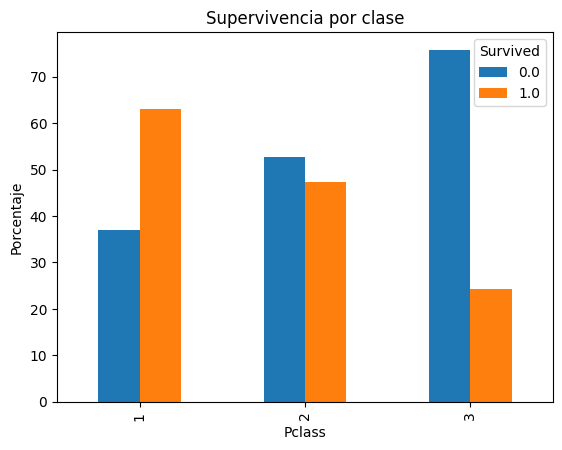

In [141]:
tabla_4.plot(kind="bar")
plt.ylabel("Porcentaje")
plt.title("Supervivencia por clase")
plt.show()

A partir de la tabla de contingencia se observa que la proporción de sobrevivientes varía según la clase del pasajero. En particular, la primera clase presenta la mayor proporción de supervivencia, seguida por la segunda clase, mientras que la tercera clase presenta la menor proporción de sobrevivientes.

Esto evidencia una relación entre la clase socioeconómica y las probabilidades de supervivencia en el naufragio del Titanic.